# Ансамбли: пригодность воды для питья (Potability)

**Датасет:** `water_potability.csv`  
**Цель:** `Potability` — 1 = вода пригодна, 0 = нет.


# 1. Анализ данных и базовые модели


## 1.1. Загрузка и разведочный анализ (EDA)


In [195]:
# Импорты
import time  # замер времени обучения бустингов
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
    StackingClassifier, HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay,
)

sns.set_theme(style="whitegrid")
np.random.seed(42)
pd.set_option("display.max_columns", 50)

DATA_PATH = "water_potability.csv"
df = pd.read_csv(DATA_PATH)

print("Размер:", df.shape)


Размер: (3276, 10)


In [196]:
# Структура, пропуски, баланс классов
print("=== info ===")
df.info()
print("\n=== пропуски ===")
print(df.isna().sum().sort_values(ascending=False))
print("Всего NaN:", int(df.isna().sum().sum()))
print("\n=== Potability ===")
print(df["Potability"].value_counts())
print(df["Potability"].value_counts(normalize=True).round(3))


=== info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB

=== пропуски ===
Sulfate            781
ph                 491
Trihalomethanes    162
Hardness             0
Solids               0
Chloramines          0
Conductivity         0
Organic_carbon       0
Turbidity            0
Potability           0
dtype: int64
Всего NaN: 1434

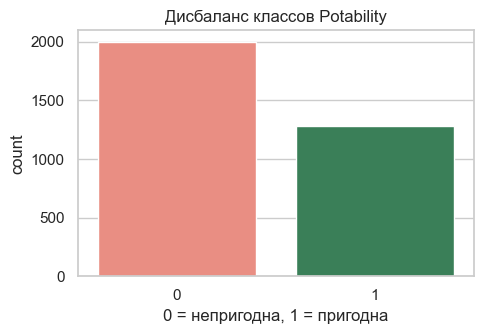

In [197]:
# Распределение целевой переменной
fig, ax = plt.subplots(figsize=(5, 3.5))
# countplot: сколько объектов каждого класса
sns.countplot(data=df, x="Potability", hue="Potability",
              palette=["salmon", "seagreen"], legend=False, ax=ax)
ax.set_title("Дисбаланс классов Potability")
ax.set_xlabel("0 = непригодна, 1 = пригодна")
plt.tight_layout()
plt.show()


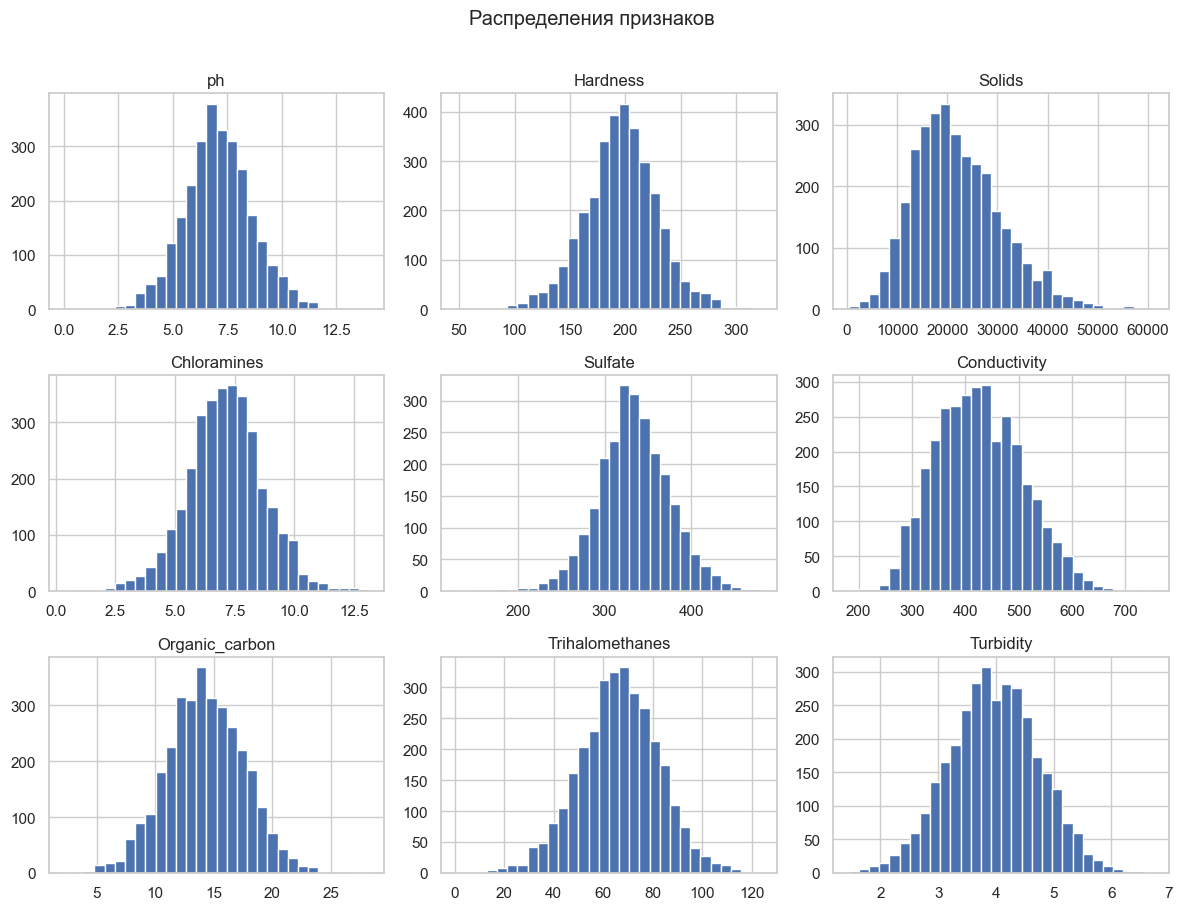

In [198]:
# Гистограммы признаков
feat_cols = [c for c in df.columns if c != "Potability"]
# Рисуем распределения всех физико-химических показателей
df[feat_cols].hist(bins=30, figsize=(12, 9), edgecolor="white")
plt.suptitle("Распределения признаков", y=1.01)
plt.tight_layout()
plt.show()


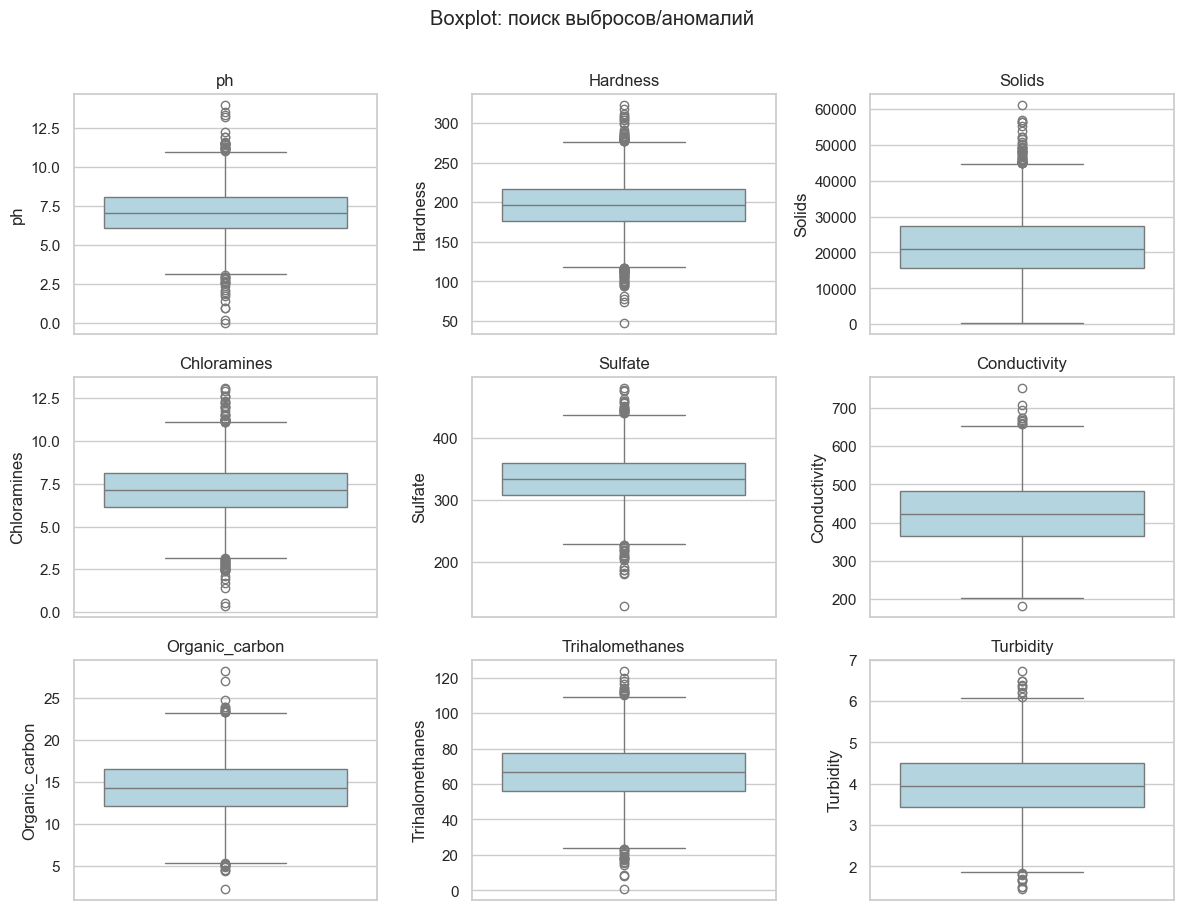

In [199]:
# Аномалии: boxplot по признакам
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.ravel()
for i, col in enumerate(feat_cols):
    # Ящик с усами помогает увидеть выбросы
    sns.boxplot(data=df, y=col, ax=axes[i], color="lightblue")
    axes[i].set_title(col)
plt.suptitle("Boxplot: поиск выбросов/аномалий", y=1.01)
plt.tight_layout()
plt.show()


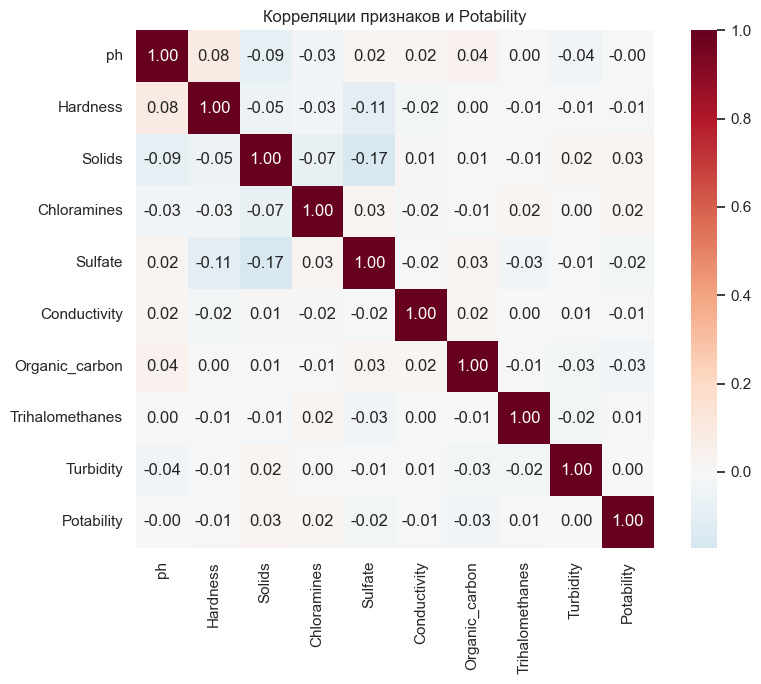

Корреляции с Potability (по |r|):
Solids             0.034
Organic_carbon     0.030
Chloramines        0.024
Sulfate            0.024
Hardness           0.014
Conductivity       0.008
Trihalomethanes    0.007
ph                 0.004
Turbidity          0.002
Name: Potability, dtype: float64


In [200]:
# Тепловая карта корреляций
corr = df.corr(numeric_only=True)
plt.figure(figsize=(9, 7))
# annot=True — числа в клетках; center=0 — нейтральный ноль
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Корреляции признаков и Potability")
plt.tight_layout()
plt.show()

print("Корреляции с Potability (по |r|):")
print(corr["Potability"].drop("Potability").abs().sort_values(ascending=False).round(3))


### Выводы по первичному анализу данных

1. В признаках Sulfate, ph и Trihalomethanes много пропусков; их целесообразно заполнять медианой, так как она устойчивее к выбросам, чем среднее.

2. Целевая переменная несбалансирована: класс пригодной воды встречается реже (~39% против ~61%). Поэтому при разбиении данных нужно использовать stratify, а для некоторых моделей учитывать class_weight='balanced'.

3. Корреляция признаков с целевой переменной в целом слабая, значит задача сложная и один признак сам по себе не решает её.

4. Есть выбросы, но они не критичны для деревьев и лесов; для линейных моделей и SVM важно масштабирование признаков.

5. Оценивать качество модели стоит не только по Accuracy, но и по Precision, Recall, F1 и ROC-AUC для класса 1.


## 1.2. Предобработка и разделение выборки


In [201]:
# Отделяем признаки и цель
y = df["Potability"].copy()
X = df.drop(columns=["Potability"]).copy()

# Список числовых колонок (здесь все признаки числовые)
num_features = list(X.columns)

# Пайплайн для моделей, которым нужен scale (LR, SVM):
# 1) медиана в пропусках  2) стандартизация
pipe_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # NaN - медиана столбца
    ("scaler", StandardScaler()),                   # среднее 0, разброс 1
])

# Для деревьев/лес/бустинг scale обычно не обязателен — только импутация
pipe_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

# Делим 80/20 с сохранением доли классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "доля Potable =", round(y_train.mean(), 3))
print("Test: ", X_test.shape, "доля Potable =", round(y_test.mean(), 3))


Train: (2620, 9) доля Potable = 0.39
Test:  (656, 9) доля Potable = 0.39


## 1.3. Базовые модели: LogReg, SVM, Decision Tree


In [202]:
# Функция оценки одной модели на test (+ опционально train)
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    # Запоминаем время обучения
    t0 = time.time()
    # Учим модель (внутри Pipeline: impute/scale + классификатор)
    model.fit(X_tr, y_tr)
    fit_sec = time.time() - t0

    # Классы на test
    y_pred = model.predict(X_te)
    # Вероятности класса 1 нужны для ROC-AUC
    y_proba = model.predict_proba(X_te)[:, 1]


    # Метрики: accuracy общая; precision/recall/f1 — для класса 1 (пригодная вода)
    row = {
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, y_proba),
        "fit_sec": fit_sec,
        # Для диагностики смещение/дисперсия: качество на train
        "acc_train": accuracy_score(y_tr, model.predict(X_tr)),
    }
    return row, model, y_pred, y_proba


In [203]:
# Собираем три базовые модели
# class_weight='balanced' — сильнее штрафует ошибки на редком классе (Potability=1)
base_models = {
    "LogisticRegression": Pipeline([
        ("prep", clone(pipe_scaled)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ]),
    "SVM": Pipeline([
        ("prep", clone(pipe_scaled)),
        # probability=True нужно для predict_proba / ROC-AUC
        ("clf", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
    ]),
    "DecisionTree": Pipeline([
        ("prep", clone(pipe_tree)),
        ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=42)),
    ]),
}

results = []          # строки таблицы метрик
fitted = {}           # обученные модели
probas = {}           # вероятности на test для ROC

#сборка и сравнение всех базовых моделей
for name, model in base_models.items():
    row, fitted_model, y_pred, y_proba = evaluate(
        name, model, X_train, y_train, X_test, y_test
    )
    results.append(row)
    fitted[name] = fitted_model
    probas[name] = y_proba
    print(f"Готово: {name}")

base_table = pd.DataFrame(results).sort_values("f1", ascending=False)
print("\n=== Базовые модели (test) ===")
print(base_table.round(4).to_string(index=False))


Готово: LogisticRegression
Готово: SVM
Готово: DecisionTree

=== Базовые модели (test) ===
             model  accuracy  precision  recall     f1  roc_auc  fit_sec  acc_train
               SVM    0.6220     0.5159  0.5078 0.5118   0.6440   0.6558     0.7538
      DecisionTree    0.5945     0.4797  0.4609 0.4701   0.5705   0.0406     1.0000
LogisticRegression    0.5244     0.4146  0.5312 0.4658   0.5474   0.0105     0.5206


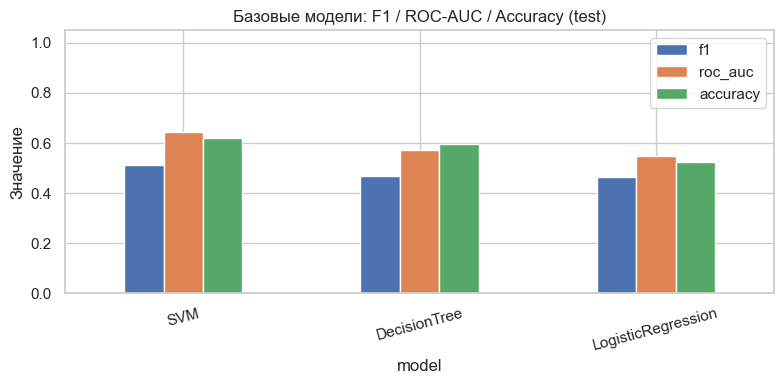

             model  acc_train  accuracy  gap_acc
               SVM     0.7538    0.6220   0.1319
      DecisionTree     1.0000    0.5945   0.4055
LogisticRegression     0.5206    0.5244  -0.0038


In [204]:
# Столбчатый график F1 / ROC-AUC базовых моделей
plot_df = base_table.set_index("model")[["f1", "roc_auc", "accuracy"]]
ax = plot_df.plot(kind="bar", figsize=(8, 4), rot=15)
ax.set_ylim(0, 1.05)
ax.set_title("Базовые модели: F1 / ROC-AUC / Accuracy (test)")
ax.set_ylabel("Значение")
plt.tight_layout()
plt.show()

# Разрыв train−test accuracy — грубый индикатор дисперсии (переобучения)
base_table["gap_acc"] = base_table["acc_train"] - base_table["accuracy"]
print(base_table[["model", "acc_train", "accuracy", "gap_acc"]].round(4).to_string(index=False))


### Анализ базовых моделей (смещение–дисперсия)

| Модель | Типичное поведение |
|--------|-------------------|
| **LogReg** | Высокое **смещение** (простая линейная граница), низкая дисперсия — стабильна, но может недообучаться |
| **SVM (RBF)** | Гибче LogReg, средняя сложность — баланс зависит от `C`/`gamma` |
| **Decision Tree** | Низкое смещение / **высокая дисперсия** — легко переобучается (огромный gap train−test) |

**Лучшую базовую** выбираем по **F1** и **ROC-AUC** на test (с учётом дисбаланса). Её дальше сравниваем с ансамблями.


In [205]:
# Фиксируем имя лучшей базовой модели по F1
best_base_name = base_table.iloc[0]["model"]
print("Лучшая базовая модель по F1:", best_base_name)
print(base_table.drop(columns=["model"]).iloc[0].round(4))


Лучшая базовая модель по F1: SVM
accuracy     0.6220
precision    0.5159
recall       0.5078
f1           0.5118
roc_auc      0.6440
fit_sec      0.6558
acc_train    0.7538
gap_acc      0.1319
Name: 1, dtype: float64


# 2. Bagging и случайный лес


## 2.1. BaggingClassifier — разное число деревьев и параметры

- берём много деревьев,
- каждое дерево обучаем на своей случайной выборке,
- потом все деревья голосуют вместе.

Основная цель — сделать модель более стабильной и менее “чувствительной” к случайностям в данных.

In [206]:
# Эксперимент: проверяем, как качество Bagging меняется при разном числе деревьев
n_list = [10, 30, 50, 70, 100]   # список значений n_estimators: сколько деревьев будем пробовать
bag_rows = []                     # список для хранения метрик каждой конфигурации Bagging

for n in n_list:
    # Для каждого n создаём модель Bagging: несколько деревьев, обученных на случайных подвыборках
    model = Pipeline([
        ("prep", clone(pipe_tree)),  # повторно используем тот же препроцессинг, что и для деревьев
        ("clf", BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),  # базовый алгоритм внутри ансамбля
            n_estimators=n,       # сколько деревьев в комитете
            max_samples=0.8,      # на каждое дерево берём 80% строк из обучающей выборки
            max_features=1.0,     # используем все признаки для каждого дерева
            n_jobs=-1,            # параллельное обучение на всех ядрах процессора
            random_state=42,      # фиксируем случайность для воспроизводимости
        )),
    ])
    # Обучаем модель и оцениваем её на тестовой выборке
    row, _, _, y_proba = evaluate(
        f"Bagging_n={n}", model, X_train, y_train, X_test, y_test
    )
    # Сохраняем метрики этой модели в список
    bag_rows.append(row)
    # Сохраняем вероятности класса 1, чтобы потом можно было строить ROC-кривые
    probas[row["model"]] = y_proba

# Создаём таблицу со всеми результатами для разных n_estimators
bag_n_table = pd.DataFrame(bag_rows)
print(bag_n_table[["model", "f1", "roc_auc", "accuracy", "fit_sec"]].round(4).to_string(index=False))


        model     f1  roc_auc  accuracy  fit_sec
 Bagging_n=10 0.4236   0.6364    0.6433   2.6992
 Bagging_n=30 0.4286   0.6564    0.6585   0.1234
 Bagging_n=50 0.4372   0.6537    0.6585   0.2638
 Bagging_n=70 0.4372   0.6519    0.6585   0.2364
Bagging_n=100 0.4405   0.6477    0.6631   0.3946


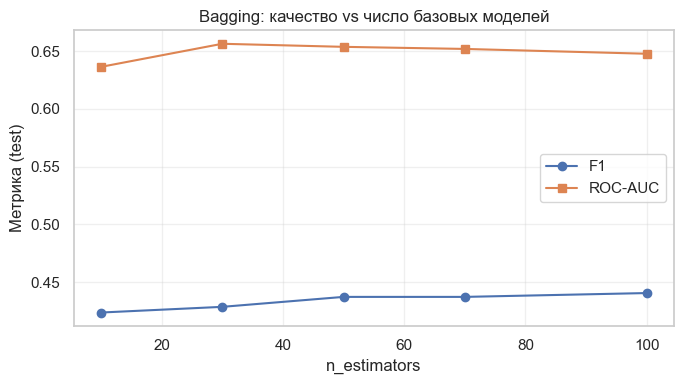

In [207]:
# График: качество vs число деревьев в бэггинге
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_list, bag_n_table["f1"], "o-", label="F1")
ax.plot(n_list, bag_n_table["roc_auc"], "s-", label="ROC-AUC")
ax.set_xlabel("n_estimators")
ax.set_ylabel("Метрика (test)")
ax.set_title("Bagging: качество vs число базовых моделей")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [208]:
# Влияние max_samples и max_features (фиксируем n_estimators=50)
# Список для хранения результатов разных настроек Bagging
bag_param_rows = []

# Перебираем разные комбинации доли объектов и доли признаков в каждом дереве
for max_samples, max_features in [(0.5, 0.5), (0.5, 1.0), (0.8, 0.5), (0.8, 1.0), (1.0, 0.5)]:
    # Создаём модель Bagging с фиксированным числом деревьев = 50
    model = Pipeline([
        ("prep", clone(pipe_tree)),  # повторно используем предобработку для деревьев
        ("clf", BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),  # базовый алгоритм внутри ансамбля
            n_estimators=50,             # фиксируем число деревьев в ансамбле
            max_samples=max_samples,     # доля объектов в каждой подвыборке
            max_features=max_features,   # доля признаков в каждой подвыборке
            n_jobs=-1,                   # параллельное обучение
            random_state=42,             # фиксируем случайность для воспроизводимости
        )),
    ])
    # Имя конфигурации для дальнейшего сравнения
    name = f"Bag_ms={max_samples}_mf={max_features}"
    # Обучаем модель и оцениваем её на тесте
    row, _, _, y_proba = evaluate(name, model, X_train, y_train, X_test, y_test)
    # Добавляем метрики этой конфигурации в список
    bag_param_rows.append(row)
    # Сохраняем вероятности для построения ROC-кривых
    probas[name] = y_proba

# Создаём DataFrame из всех оценок разных комбинаций параметров
bag_param_table = pd.DataFrame(bag_param_rows)

# Выводим итоговую таблицу по F1, ROC-AUC и accuracy для каждой конфигурации
print(bag_param_table[["model", "f1", "roc_auc", "accuracy"]].round(4).to_string(index=False))


            model     f1  roc_auc  accuracy
Bag_ms=0.5_mf=0.5 0.2202   0.5599    0.6113
Bag_ms=0.5_mf=1.0 0.4021   0.6454    0.6509
Bag_ms=0.8_mf=0.5 0.2683   0.5772    0.6341
Bag_ms=0.8_mf=1.0 0.4372   0.6537    0.6585
Bag_ms=1.0_mf=0.5 0.2622   0.5663    0.6311


### Вывод

1. **Больше деревьев (`n_estimators`)** обычно чуть поднимает F1/ROC-AUC и делает результат стабильнее: одно «случайное» дерево меньше портит ответ. После ~50–100 деревьев прирост часто замедляется.  
2. **`max_samples` / `max_features`**: слишком маленькие доли (например 0.5 и 0.5) сильно режут информацию и из-за этого качество падает. Ближе к полным данным (например `max_samples≈0.8`, `max_features=1.0`) бэггинг работает лучше на этой задаче.  
3. **Итог:** бэггинг уже лучше одиночного переобученного дерева за счёт усреднения.


## 2.2. RandomForest + подбор гиперпараметров


In [209]:
# Сетка параметров для RandomForest:
# Подбираем не слишком много вариантов, чтобы не ждать слишком долго.
# Проверяем разные количества деревьев, глубину и число признаков в каждом узле.
rf_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10, 20],
    "clf__max_features": ["sqrt", 0.5],
}

# Создаём конвейер: сначала заполняем пропуски, потом обучаем лес.
# clone(pipe_tree) копирует тот же этап подготовки данных, что и раньше.
rf_pipe = Pipeline([
    ("prep", clone(pipe_tree)),
    ("clf", RandomForestClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
    )),
])

# StratifiedKFold делит данные так, чтобы в каждом фолде сохранилась доля классов.
# Это важно, потому что классы в датасете не сбалансированы.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Поиск по сетке параметров: перебираем все комбинации и выбираем лучшую по F1.
# F1 — хороший метрика для несбалансированных задач.
rf_search = GridSearchCV(
    rf_pipe,
    param_grid=rf_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
# Подбираем параметры только на обучающей выборке, чтобы не "подглядывать" в тест.
rf_search.fit(X_train, y_train)

print("Лучшие параметры RF:", rf_search.best_params_)
print("Best CV F1:", round(rf_search.best_score_, 4))

# Берём лучшую модель из GridSearchCV и оцениваем её на тестовой выборке.
# evaluate() вернёт метрики, саму модель и вероятности класса 1.
row_rf, fitted["RandomForest"], _, y_proba_rf = evaluate(
    "RandomForest", rf_search.best_estimator_, X_train, y_train, X_test, y_test
)
# Сохраняем вероятности для дальнейшего построения ROC-кривых.
probas["RandomForest"] = y_proba_rf
# Добавляем строку метрик в общий список результатов.
results = [r for r in results if r["model"] != "RandomForest"]
results.append(row_rf)

# Ищем лучший вариант Bagging среди эксперимента с разным количеством деревьев.
# Сортируем результаты по F1 и берём самый лучший.
best_bag_row = bag_n_table.sort_values("f1", ascending=False).iloc[0].to_dict()
# В строке типа "Bagging_n=50" извлекаем число 50.
best_n = int(best_bag_row["model"].split("=")[1])
# Создаём новый ансамбль с тем количеством деревьев, которое показало лучший результат.
bag_best = Pipeline([
    ("prep", clone(pipe_tree)),
    ("clf", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=best_n,
        max_samples=0.8,
        max_features=1.0,
        n_jobs=-1,
        random_state=42,
    )),
])
# Проверяем лучшую версию Bagging на тесте.
row_bag, fitted["Bagging"], _, y_proba_bag = evaluate(
    "Bagging", bag_best, X_train, y_train, X_test, y_test
)
# Сохраняем вероятности и результат для сравнения с RandomForest.
probas["Bagging"] = y_proba_bag
results = [r for r in results if r["model"] != "Bagging"]
results.append(row_bag)

print("\nRF vs Bagging (test):")
print(pd.DataFrame([row_bag, row_rf])[
    ["model", "f1", "roc_auc", "accuracy", "acc_train", "fit_sec"]
].round(4).to_string(index=False))


Лучшие параметры RF: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__n_estimators': 100}
Best CV F1: 0.474

RF vs Bagging (test):
       model     f1  roc_auc  accuracy  acc_train  fit_sec
     Bagging 0.4405   0.6477    0.6631      1.000   0.3630
RandomForest 0.4373   0.6620    0.6509      0.921   0.1507


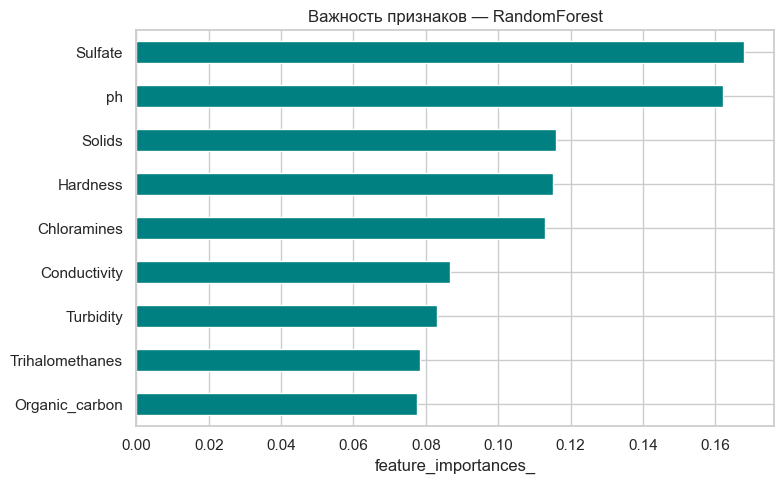

Sulfate            0.1678
ph                 0.1620
Solids             0.1160
Hardness           0.1152
Chloramines        0.1130
Conductivity       0.0866
Turbidity          0.0832
Trihalomethanes    0.0785
Organic_carbon     0.0777
dtype: float64


In [210]:
# Важность признаков случайного леса
# Достаём сам RandomForest из Pipeline
rf_clf = fitted["RandomForest"].named_steps["clf"]
# Импутация уже внутри pipeline; importances_ соответствуют исходным именам столбцов X
imp = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
imp.plot(kind="barh", color="teal")
plt.title("Важность признаков — RandomForest")
plt.xlabel("feature_importances_")
plt.tight_layout()
plt.show()

print(imp.sort_values(ascending=False).round(4))


### Физико-химический смысл важных признаков

По RandomForest сильнее всего влияют **Sulfate** и **ph** (~0.16–0.17), затем **Solids**, **Hardness**, **Chloramines** (~0.11). Слабее — Conductivity, Turbidity, Trihalomethanes, Organic_carbon.

Это логично: сульфаты и кислотность — базовые маркеры состава воды; жёсткость и растворённые вещества описывают минерализацию; хлорамины связаны с обеззараживанием. Модель опирается именно на такие «химические» сигналы, а не на один доминирующий признак.

Вывод: по F1 модели почти одинаковы, но RandomForest лучше по ROC-AUC и менее переобучается. Для этой задачи он предпочтительнее.


# 3. Boosting: AdaBoost, Gradient Boosting, XGBoost


## 3.1. AdaBoost

Много простых деревьев учатся по очереди: каждое сильнее исправляет ошибки предыдущих, потом голосуют вместе.

Нужен, чтобы показать бустинг (последовательно), а не бэггинг/лес (параллельно).

In [211]:
# Подбираем параметры для AdaBoost: сколько деревьев и насколько быстро они корректируют ошибки.
# Чем больше деревьев, тем сильнее модель, но и выше риск переобучения.
ada_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.05, 0.1, 0.5, 1.0],
}

# Сначала заполняем пропуски, потом обучаем ансамбль.
# Базовый алгоритм — очень простое дерево, чтобы ансамбль учился по шагам.
ada_pipe = Pipeline([
    ("prep", clone(pipe_tree)),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        random_state=42,
    )),
])

# Ищем лучшие настройки на обучающей выборке с помощью кросс-валидации.
# Смотрим именно метрику F1, потому что у нас несбалансированный класс.
ada_search = GridSearchCV(
    ada_pipe, ada_grid, scoring="f1", cv=cv, n_jobs=-1, refit=True
)
# Учимся на train и подбираем лучшие параметры.
ada_search.fit(X_train, y_train)

print("AdaBoost best params:", ada_search.best_params_)
print("AdaBoost best CV F1:", round(ada_search.best_score_, 4))

# Берём наилучшую найденную конфигурацию и проверяем её на тесте.
row_ada, fitted["AdaBoost"], _, y_proba_ada = evaluate(
    "AdaBoost", ada_search.best_estimator_, X_train, y_train, X_test, y_test
)
# Сохраняем вероятности, чтобы потом сравнить модели по ROC-кривым.
probas["AdaBoost"] = y_proba_ada
# Добавляем метрики этой модели в общий список результатов.
results = [r for r in results if r["model"] != "AdaBoost"]
results.append(row_ada)
print(pd.Series({k:v for k,v in row_ada.items() if k!="model"}).astype(float).round(4))


AdaBoost best params: {'clf__learning_rate': 1.0, 'clf__n_estimators': 200}
AdaBoost best CV F1: 0.2051
accuracy     0.6204
precision    0.6061
recall       0.0781
f1           0.1384
roc_auc      0.5863
fit_sec      0.5561
acc_train    0.6279
dtype: float64


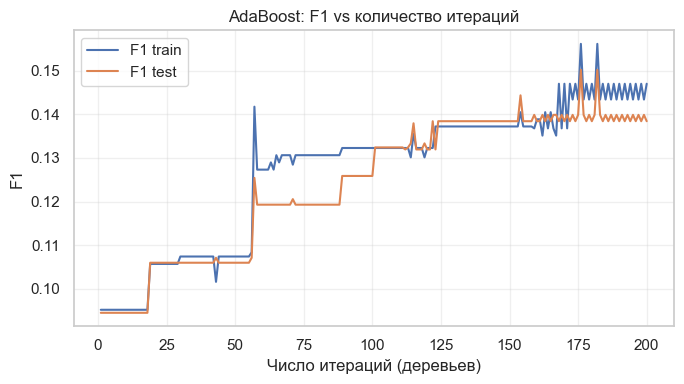

In [212]:
# Берём уже обученный AdaBoost и смотрим, как качество меняется по мере добавления деревьев.
# Поэтапно оцениваем модель после каждого нового дерева.
ada_clf = fitted["AdaBoost"].named_steps["clf"]
# Сначала подготавливаем обучающие и тестовые данные через этап prep из pipeline.
X_tr_imp = fitted["AdaBoost"].named_steps["prep"].transform(X_train)
X_te_imp = fitted["AdaBoost"].named_steps["prep"].transform(X_test)

# staged_predict возвращает предсказания после каждого шага обучения.
# Сравниваем F1 на train и test для разных количества деревьев.
ada_f1_te, ada_f1_tr = [], []
for y_tr_s, y_te_s in zip(
    ada_clf.staged_predict(X_tr_imp),
    ada_clf.staged_predict(X_te_imp),
):
    # Считаем F1 на обучающей выборке после текущего числа деревьев.
    ada_f1_tr.append(f1_score(y_train, y_tr_s, zero_division=0))
    # Считаем F1 на тестовой выборке после текущего числа деревьев.
    ada_f1_te.append(f1_score(y_test, y_te_s, zero_division=0))

plt.figure(figsize=(7, 4))
# Рисуем F1 на train и на test в зависимости от числа деревьев.
plt.plot(range(1, len(ada_f1_tr) + 1), ada_f1_tr, label="F1 train")
plt.plot(range(1, len(ada_f1_te) + 1), ada_f1_te, label="F1 test")
plt.xlabel("Число итераций (деревьев)")
plt.ylabel("F1")
plt.title("AdaBoost: F1 vs количество итераций")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


AdaBoost учит деревья **по очереди**, сильнее «наказывая» прошлые ошибки.  
В нашем прогоне качество по F1 оказалось **слабым** (модель почти не ловит класс «пригодна»), зато видно идею бустинга и график F1 по числу итераций. 


## 3.2. Gradient Boosting

Тоже учит модели по очереди, но каждое новое дерево чинит остаток ошибки предыдущих (куда модель ещё недотягивает).

Простыми словами: не просто «больше внимания к ошибочным объектам» (как AdaBoost), а шаг за шагом уменьшаем ошибку целиком.

In [213]:
# Подбираем параметры для GradientBoosting: сколько деревьев и как быстро они учатся.
gb_grid = {
    "clf__n_estimators": [100, 200],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [2, 3],
}

# Сначала обработка пропусков, а потом бустинг.
gb_pipe = Pipeline([
    ("prep", clone(pipe_tree)),
    ("clf", GradientBoostingClassifier(random_state=42)),
])

# Ищем лучшие комбинации на обучении, оценивая их по F1.
gb_search = GridSearchCV(
    gb_pipe, gb_grid, scoring="f1", cv=cv, n_jobs=-1, refit=True
)
# Обучаем модель на train и выбираем лучшую комбинацию параметров.
gb_search.fit(X_train, y_train)

print("GB best params:", gb_search.best_params_)
print("GB best CV F1:", round(gb_search.best_score_, 4))

# Берём лучшую модель и тестируем её на тестовой выборке.
row_gb, fitted["GradientBoosting"], _, y_proba_gb = evaluate(
    "GradientBoosting", gb_search.best_estimator_, X_train, y_train, X_test, y_test
)
# Сохраняем вероятности класса 1 для ROC-кривых и сравнения моделей.
probas["GradientBoosting"] = y_proba_gb
# Добавляем результаты в общий список метрик.
results = [r for r in results if r["model"] != "GradientBoosting"]
results.append(row_gb)
print(pd.Series({k:v for k,v in row_gb.items() if k!="model"}).astype(float).round(4))


GB best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}
GB best CV F1: 0.4138
accuracy     0.6540
precision    0.6142
recall       0.3047
f1           0.4073
roc_auc      0.6558
fit_sec      1.2565
acc_train    0.8015
dtype: float64


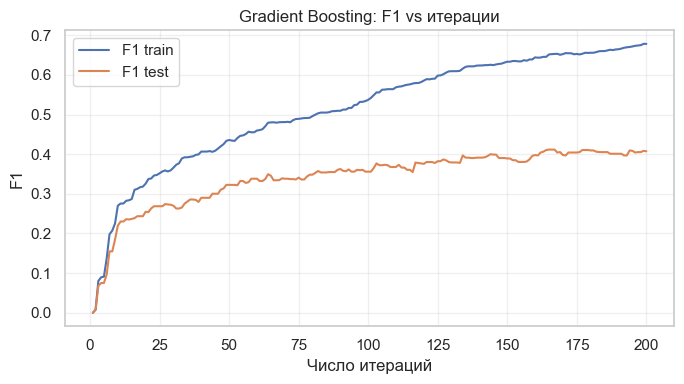

In [214]:
# Берём уже обученный GradientBoosting и смотрим, как качество меняется по мере роста числа деревьев.
# Это нужно, чтобы понять, не началось ли переобучение.
gb_clf = fitted["GradientBoosting"].named_steps["clf"]
# Подготавливаем данные через шаг prep, чтобы получить те же признаки, что использовались при обучении.
X_tr_imp = fitted["GradientBoosting"].named_steps["prep"].transform(X_train)
X_te_imp = fitted["GradientBoosting"].named_steps["prep"].transform(X_test)

# staged_predict возвращает предсказания после каждого добавленного дерева.
# Считаем F1 на train и test для каждого этапа.
gb_f1_te, gb_f1_tr = [], []
for y_tr_s, y_te_s in zip(
    gb_clf.staged_predict(X_tr_imp),
    gb_clf.staged_predict(X_te_imp),
):
    # F1 на обучении: показывает, как хорошо модель уже учится.
    gb_f1_tr.append(f1_score(y_train, y_tr_s, zero_division=0))
    # F1 на тесте: показывает, насколько хорошо модель обобщает.
    gb_f1_te.append(f1_score(y_test, y_te_s, zero_division=0))

plt.figure(figsize=(7, 4))
# Рисуем кривые качества на train и test.
plt.plot(range(1, len(gb_f1_tr) + 1), gb_f1_tr, label="F1 train")
plt.plot(range(1, len(gb_f1_te) + 1), gb_f1_te, label="F1 test")
plt.xlabel("Число итераций")
plt.ylabel("F1")
plt.title("Gradient Boosting: F1 vs итерации")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


GB строит деревья **по очереди**, каждое уменьшает общую ошибку.  
У нас F1 заметно **выше, чем у AdaBoost**, но train всё ещё выше test — при большом числе итераций нужно следить за переобучением (`learning_rate`, `max_depth`).


## 3.3. XGBoost
AdaBoost — исправляет ошибки предыдущих моделей, Gradient Boosting — постепенно уменьшает ошибки с помощью градиента, а XGBoost — это более быстрый, оптимизированный и улучшенный вариант Gradient Boosting.

In [215]:
# Сетка параметров для XGBoost: количество деревьев, скорость обучения и глубина.
xgb_grid = {
    "clf__n_estimators": [100, 200],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [3, 5],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}
# Сначала подготовка данных, затем XGBoost.
xgb_pipe = Pipeline([
    ("prep", clone(pipe_tree)),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )),
])

model_label = "XGBoost"

# Подбираем параметры по F1 через кросс-валидацию.
xgb_search = GridSearchCV(
    xgb_pipe, xgb_grid, scoring="f1", cv=cv, n_jobs=-1, refit=True
)
# Обучаем поиск на train и выбираем лучшую конфигурацию.
xgb_search.fit(X_train, y_train)

print(model_label, "best params:", xgb_search.best_params_)
print(model_label, "best CV F1:", round(xgb_search.best_score_, 4))

# Берём лучшую модель и оцениваем её на тестовой выборке.
row_xgb, fitted[model_label], _, y_proba_xgb = evaluate(
    model_label, xgb_search.best_estimator_, X_train, y_train, X_test, y_test
)
# Сохраняем вероятности класса 1 для ROC-кривых.
probas[model_label] = y_proba_xgb
# Добавляем/обновляем результат в общем списке (без дублей при повторном запуске).
results = [r for r in results if r["model"] != model_label]
results.append(row_xgb)
print(pd.Series({k:v for k,v in row_xgb.items() if k!="model"}).astype(float).round(4))


XGBoost best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
XGBoost best CV F1: 0.4843
accuracy     0.6402
precision    0.5588
recall       0.3711
f1           0.4460
roc_auc      0.6340
fit_sec      0.2413
acc_train    0.9660
dtype: float64


           model     f1  roc_auc  accuracy  fit_sec  acc_train
        AdaBoost 0.1384   0.5863    0.6204   0.5561     0.6279
GradientBoosting 0.4073   0.6558    0.6540   1.2565     0.8015
         XGBoost 0.4460   0.6340    0.6402   0.2413     0.9660


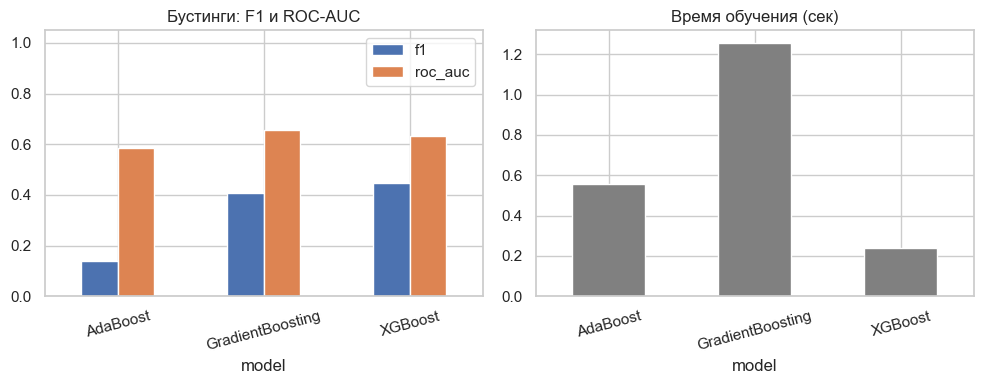

In [216]:
# Создаём таблицу только для бустингов, чтобы сравнить их между собой.
# В список включаем AdaBoost, GradientBoosting и тот вариант XGBoost, который реально использовался.
boost_names = ["AdaBoost", "GradientBoosting", model_label]
boost_table = (
    pd.DataFrame([r for r in results if r["model"] in boost_names])
    .drop_duplicates(subset=["model"], keep="last")
    .reset_index(drop=True)
)
print(boost_table[["model", "f1", "roc_auc", "accuracy", "fit_sec", "acc_train"]].round(4).to_string(index=False))

# Рисуем два графика: качество моделей и время их обучения.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Слева — сравнение F1 и ROC-AUC между бустингами.
boost_table.set_index("model")[["f1", "roc_auc"]].plot(kind="bar", ax=axes[0], rot=15)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Бустинги: F1 и ROC-AUC")
# Справа — сравнение скорости обучения.
boost_table.set_index("model")["fit_sec"].plot(kind="bar", ax=axes[1], rot=15, color="gray")
axes[1].set_title("Время обучения (сек)")
plt.tight_layout()
plt.show()


### Сравнение бустингов (смещение / дисперсия / переобучение)

| Метод | Идея | Риск переобучения |
|-------|------|-------------------|
| **AdaBoost** | Перевзвешивает ошибочные объекты | Средний; сильно зависит от `learning_rate` и шума |
| **Gradient Boosting** | Каждый шаг чинит остаток предыдущих | При большом `n_estimators` + глубоких деревьях train уходит вверх |
| **XGBoost** | Тот же градиентный бустинг + регуляризация/оптимизации | Обычно лучше контроль через `subsample`, `max_depth`, `eta` |

# 4. Stacking и финальное сравнение


## 4.1. Stacking (дерево + RF + GB - LogReg)


In [217]:
# Создаём базовые модели для стекинга: несколько разных классификаторов.
# У каждого свой тип ошибок, поэтому вместе они могут давать более устойчивый результат.
estimators = [
    ("tree", Pipeline([
        ("prep", clone(pipe_tree)),
        ("clf", DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)),
    ])),
    ("rf", Pipeline([
        ("prep", clone(pipe_tree)),
        ("clf", RandomForestClassifier(
            n_estimators=150, max_depth=15, class_weight="balanced",
            n_jobs=-1, random_state=42
        )),
    ])),
    ("gb", Pipeline([
        ("prep", clone(pipe_tree)),
        ("clf", GradientBoostingClassifier(
            n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42
        )),
    ])),
]

# Мета-модель — логистическая регрессия, которая learns на предсказаниях базовых моделей.
# stack_method="predict_proba" значит, что в качестве признаков для мета-модели подаём вероятности классов.
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    stack_method="predict_proba",
    cv=3,
    n_jobs=-1,
)

# Оцениваем стек на тестовой выборке.
row_stack, fitted["Stacking"], _, y_proba_stack = evaluate(
    "Stacking", stack, X_train, y_train, X_test, y_test
)
# Сохраняем вероятности и добавляем метрики в общий список.
probas["Stacking"] = y_proba_stack
results = [r for r in results if r["model"] != "Stacking"]
results.append(row_stack)
print(pd.Series({k:v for k,v in row_stack.items() if k!="model"}).astype(float).round(4))


accuracy     0.6250
precision    0.5179
recall       0.5664
f1           0.5410
roc_auc      0.6824
fit_sec      1.9272
acc_train    0.9977
dtype: float64


In [218]:
# Это ещё один стек, но уже из LogReg, SVM и RandomForest.
# Проверяем, будет ли другой набор базовых моделей работать лучше.
estimators2 = [
    ("lr", Pipeline([
        ("prep", clone(pipe_scaled)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ])),
    ("svm", Pipeline([
        ("prep", clone(pipe_scaled)),
        ("clf", SVC(probability=True, class_weight="balanced", random_state=42)),
    ])),
    ("rf", Pipeline([
        ("prep", clone(pipe_tree)),
        ("clf", RandomForestClassifier(
            n_estimators=150, class_weight="balanced", n_jobs=-1, random_state=42
        )),
    ])),
]

# Создаём второй стек: на основе вероятностей базовых моделей будет обучаться логистическая регрессия.
stack2 = StackingClassifier(
    estimators=estimators2,
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    stack_method="predict_proba",
    cv=3,
    n_jobs=-1,
)

# Проверяем второй вариант стекинга на тесте.
row_stack2, fitted["Stacking_v2"], _, y_proba_stack2 = evaluate(
    "Stacking_v2", stack2, X_train, y_train, X_test, y_test
)
# Сохраняем вероятности и добавляем метрики в общий список.
probas["Stacking_v2"] = y_proba_stack2
results = [r for r in results if r["model"] != "Stacking_v2"]
results.append(row_stack2)
print(pd.Series({k:v for k,v in row_stack2.items() if k!="model"}).astype(float).round(4))


accuracy     0.6189
precision    0.5112
recall       0.5352
f1           0.5229
roc_auc      0.6529
fit_sec      1.6459
acc_train    0.9378
dtype: float64


## 4.2. Финальная таблица и ROC-кривые


In [219]:
# Единая таблица всех моделей
final_table = pd.DataFrame(results).drop_duplicates(subset=["model"], keep="last")
final_table = final_table.sort_values("f1", ascending=False).reset_index(drop=True)
print("=== Финальное сравнение (test) ===")
print(final_table[
    ["model", "accuracy", "precision", "recall", "f1", "roc_auc", "fit_sec", "acc_train"]
].round(4).to_string(index=False))

# Сохраняем таблицу рядом с ноутбуком
final_table.to_csv("water_ensembles_metrics.csv", index=False)
print("\nТаблица сохранена в water_ensembles_metrics.csv")


=== Финальное сравнение (test) ===
             model  accuracy  precision  recall     f1  roc_auc  fit_sec  acc_train
          Stacking    0.6250     0.5179  0.5664 0.5410   0.6824   1.9272     0.9977
       Stacking_v2    0.6189     0.5112  0.5352 0.5229   0.6529   1.6459     0.9378
               SVM    0.6220     0.5159  0.5078 0.5118   0.6440   0.6558     0.7538
      DecisionTree    0.5945     0.4797  0.4609 0.4701   0.5705   0.0406     1.0000
LogisticRegression    0.5244     0.4146  0.5312 0.4658   0.5474   0.0105     0.5206
           XGBoost    0.6402     0.5588  0.3711 0.4460   0.6340   0.2413     0.9660
           Bagging    0.6631     0.6259  0.3398 0.4405   0.6477   0.3630     1.0000
      RandomForest    0.6509     0.5894  0.3477 0.4373   0.6620   0.1507     0.9210
  GradientBoosting    0.6540     0.6142  0.3047 0.4073   0.6558   1.2565     0.8015
          AdaBoost    0.6204     0.6061  0.0781 0.1384   0.5863   0.5561     0.6279

Таблица сохранена в water_ensembles_metr

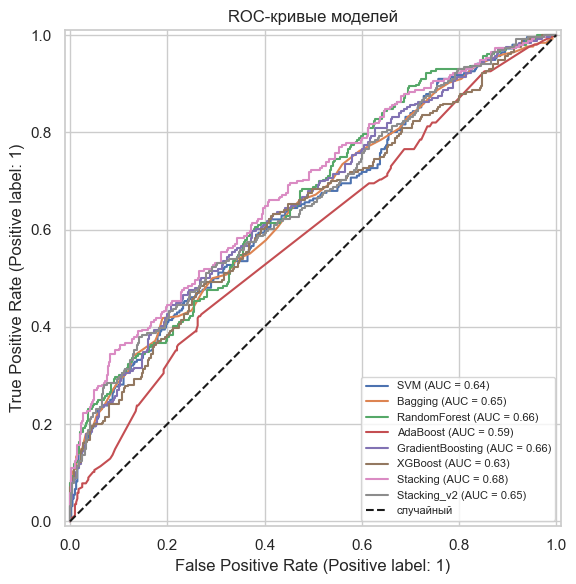

In [220]:
# ROC-кривые ключевых моделей
roc_list = [
    best_base_name, "Bagging", "RandomForest",
    "AdaBoost", "GradientBoosting", model_label,
    "Stacking", "Stacking_v2",
]
# Оставим только те, что реально посчитаны
roc_list = [m for m in roc_list if m in probas]

plt.figure(figsize=(8, 6))
ax = plt.gca()
for name in roc_list:
    # Рисуем ROC по вероятностям на test
    RocCurveDisplay.from_predictions(y_test, probas[name], name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="случайный")
ax.set_title("ROC-кривые моделей")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


In [221]:
# Важность признаков: берём RF (интерпретируемый ансамбль)
if "RandomForest" in fitted:
    rf_clf = fitted["RandomForest"].named_steps["clf"]
    imp = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("Топ признаков (RF) и физико-химический смысл:")
    meaning = {
        "ph": "кислотность воды",
        "Hardness": "жёсткость (Ca/Mg)",
        "Solids": "растворённые твёрдые вещества",
        "Chloramines": "хлорамины (дезинфекция)",
        "Sulfate": "сульфаты",
        "Conductivity": "электропроводность",
        "Organic_carbon": "органический углерод",
        "Trihalomethanes": "тригалометаны (побочные продукты хлорирования)",
        "Turbidity": "мутность",
    }
    for feat, val in imp.items():
        print(f"  {feat:18s} {val:.4f}  — {meaning.get(feat, '')}")


Топ признаков (RF) и физико-химический смысл:
  Sulfate            0.1678  — сульфаты
  ph                 0.1620  — кислотность воды
  Solids             0.1160  — растворённые твёрдые вещества
  Hardness           0.1152  — жёсткость (Ca/Mg)
  Chloramines        0.1130  — хлорамины (дезинфекция)
  Conductivity       0.0866  — электропроводность
  Turbidity          0.0832  — мутность
  Trihalomethanes    0.0785  — тригалометаны (побочные продукты хлорирования)
  Organic_carbon     0.0777  — органический углерод


## Общий вывод

Классы в задаче неравны, а признаки слабо связаны с «пить / не пить».

Лучше всего сработал Stacking — он точнее остальных находит пригодную воду (F1 ≈ 0.54, ROC-AUC ≈ 0.68). Хороший запасной вариант — случайный лес: почти то же качество, но проще и стабильнее.

Слабее: обычное дерево (переобучается), логистическая регрессия (слишком простая), AdaBoost почти не ловит пригодную воду.

Из показателей воды важнее всего сульфаты и pH, затем жёсткость, растворённые вещества и хлорамины.

На практике нужно начинать с случайного леса или stacking, смотреть F1 и ROC-AUC (не только accuracy), пропуски заполнять медианой.
